# Join datasets
- Author: Bryan Bravo
- Created: 2026-03-28
## Import Libraries

In [1]:
import os
import sys

os.chdir("C:/Users/bravo/OneDrive/bravo_projects/MLProject/StraitofHormuzResearch")
# Set JAVA_HOME before importing PySpark and use findspark
os.environ['JAVA_HOME'] = r'C:\Program Files\Java\jdk-22'  # May need to remove or update in cloud environment.
import findspark
findspark.init()

import requests
import pandas as pd
import numpy as np
import json
import pyspark
from datetime import datetime as dt
from dateutil.relativedelta import relativedelta
from functools import reduce
from pyspark.sql import (
    functions as F,
    Window as W,
    types as T,
    SparkSession,
    DataFrame
)

# Visualize data for joined dataframes.
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns


# api keys and other hardcoded values for the Strait of Hormuz Research project.
# Note: In a production environment, these should be stored securely and not hardcoded.
import hardcoded_keys # Note: This file is added to .gitignore to prevent accidental commits of sensitive information.

import proj_vars

### Initialize Spark Session


In [2]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("BusinessPlanAnalysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.hadoop.io.native.lib.available", "false") \
    .config("spark.sql.parquet.nativeio.enabled", "false") \
    .getOrCreate()

print("Spark Session created successfully!")

Spark Session created successfully!


## Variables

In [3]:
end_date = (dt.now().replace(day=1) - relativedelta(days=1)).strftime("%Y-%m-%d")
# in_path = 's3a://ml-project-s3-bronze/input_folder/'
in_path = 'processed_datasets/'
out_path = 'processed_datasets/'


## Custom Functions

## Query


In [4]:
# Read and display the first few rows of each dataset to verify they are loaded correctly.
df_list = ['acled', 'cpi', 'fred', 'gpr', 'lsci', 'oil', 'wb']
for df_name in df_list:
    globals()[f"{df_name}_df"] = spark.read.csv(f"{in_path}/{df_name}.csv", header=True, inferSchema=True)
    print(f"DataFrame: {df_name}")
    globals()[f"{df_name}_df"].show(5)


DataFrame: acled
+---------+-----+----+------+
|  country|month|year|events|
+---------+-----+----+------+
|australia|    1|2021|     2|
|australia|    2|2021|     0|
|australia|    3|2021|     0|
|australia|    4|2021|     0|
|australia|    5|2021|     1|
+---------+-----+----+------+
only showing top 5 rows

DataFrame: cpi
+---------+-----+----+-----+
|  country|value|year|month|
+---------+-----+----+-----+
|australia| 96.4|2024|    4|
|australia|96.17|2024|    5|
|australia|96.52|2024|    6|
|australia|96.77|2024|    7|
|australia|96.49|2024|    8|
+---------+-----+----+-----+
only showing top 5 rows

DataFrame: fred
+--------+---------+-------------+-------+
|    date|  country|interest_rate|fx_rate|
+--------+---------+-------------+-------+
|20060403|australia|          5.5| 0.7177|
|20060404|australia|          5.5| 0.7203|
|20060405|australia|          5.5| 0.7263|
|20060406|australia|          5.5| 0.7315|
|20060407|australia|          5.5| 0.7279|
+--------+---------+-------

## Join Datasets and Cleaning
### FRED and Oil datasets
Joining and checking for duplicates

In [16]:
# FRED and oil
joined_df1 = fred_df.join(oil_df, on='date', how='left')
print(f"Joined DataFrame (row, col) count: {(joined_df1.count(), len(joined_df1.columns))}")
print("Columns in joined_df1: ", joined_df1.columns)

## Check for duplicates
duplicate_count = joined_df1.groupBy(joined_df1.columns).count().filter("count > 1").count()
print(f"--- --- --- --- --- --- --- --- ---\nNumber of duplicate rows in joined_df1: {duplicate_count}")


Joined DataFrame (row, col) count: (60520, 6)
Columns in joined_df1:  ['date', 'country', 'interest_rate', 'fx_rate', 'brent_dollars_per_barrel', 'wti_dollars_per_barrel']
--- --- --- --- --- --- --- --- ---
Number of duplicate rows in joined_df1: 0


No duplicate rows were found.
checking for missing values

In [17]:
## Check for missing values
missing_values = {col: joined_df1.filter(joined_df1[col].isNull()).count() for col in joined_df1.columns}
print("Missing values in joined_df1:\n--- --- --- --- --- --- --- --- ---")
for col, count in missing_values.items():
    print(f"{col}: {count}")


Missing values in joined_df1:
--- --- --- --- --- --- --- --- ---
date: 0
country: 0
interest_rate: 0
fx_rate: 0
brent_dollars_per_barrel: 1278
wti_dollars_per_barrel: 1278


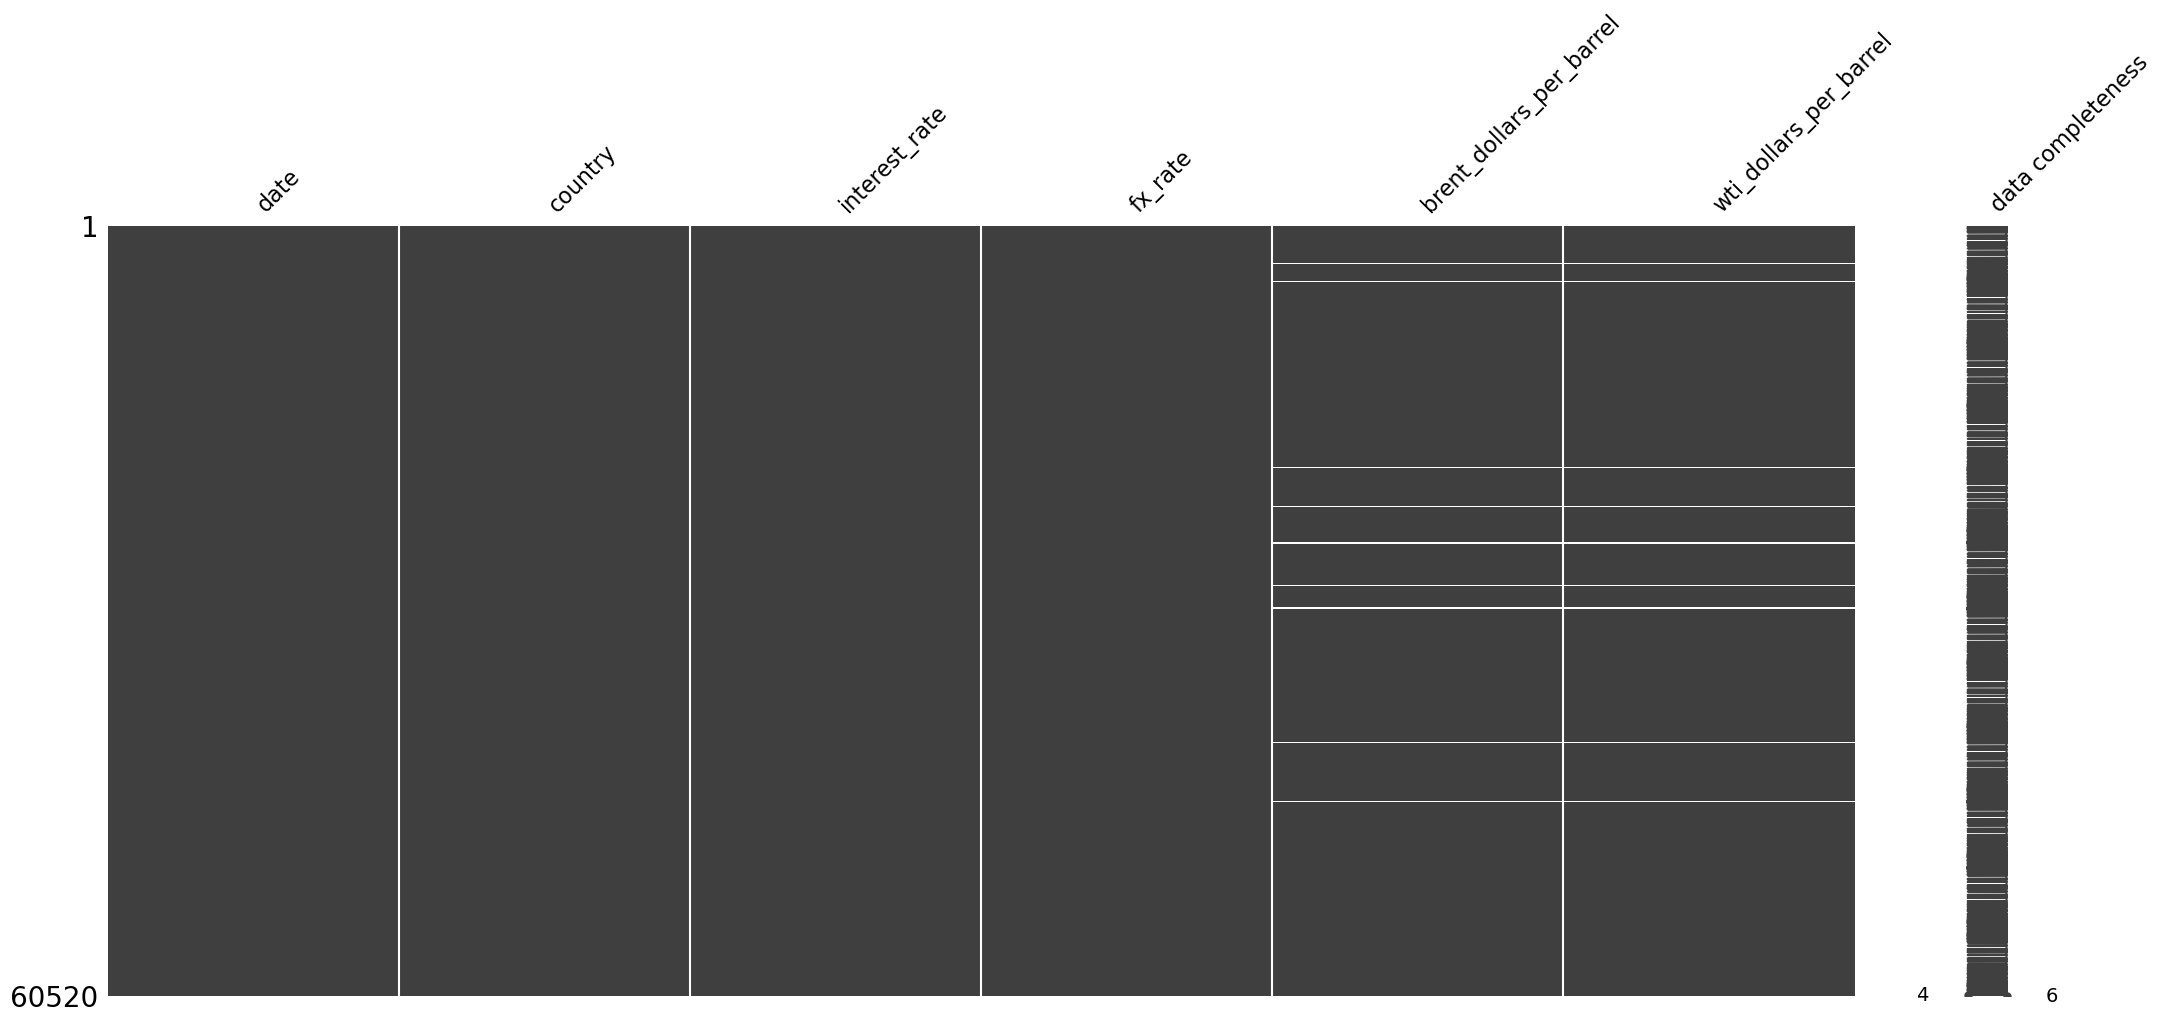

In [18]:

# Visualize missing data in the joined dataframe.
# Note: This will convert the Spark DataFrame to a Pandas DataFrame, which may not be efficient for large datasets.
msno.matrix(joined_df1.toPandas(), labels=True)
plt.show()


#### Missing data treatment
A close inspection of the dates in relation to the missing oil-price data reveals that they fall on **market holidays or non-trading days**. Oil benchmarks do not publish prices on these days. This is expected behavior.
- Using F-Fill on the missing data is applicable in this situation based on the assumption that the _true price_ is the last traded price for this analysis.

In [19]:
(joined_df1.filter(F.col('brent_dollars_per_barrel').isNull()
                   | F.col('wti_dollars_per_barrel').isNull())
.orderBy('country', 'date').show())

+--------+---------+----------------+-------+------------------------+----------------------+
|    date|  country|   interest_rate|fx_rate|brent_dollars_per_barrel|wti_dollars_per_barrel|
+--------+---------+----------------+-------+------------------------+----------------------+
|20060414|australia|             5.5| 0.7289|                    NULL|                  NULL|
|20060417|australia|             5.5| 0.7375|                    NULL|                  NULL|
|20060703|australia|            5.75| 0.7436|                    NULL|                  NULL|
|20061029|australia|             6.0| 0.7692|                    NULL|                  NULL|
|20061124|australia|6.19318181818182| 0.7782|                    NULL|                  NULL|
|20061226|australia|            6.25| 0.7829|                    NULL|                  NULL|
|20070406|australia|            6.25| 0.8177|                    NULL|                  NULL|
|20070409|australia|            6.25| 0.8167|               

In [20]:
# F-Fill missing values for oil prices in joined_df1.
w1 = W.partitionBy('country').orderBy('date')
joined_df1 = (
    joined_df1
    .withColumns({
        col: F.last(F.col(col), ignorenulls=True).over(w1) for col in ['brent_dollars_per_barrel', 'wti_dollars_per_barrel']
    })
)

## Check for missing values
missing_values = {col: joined_df1.filter(joined_df1[col].isNull()).count() for col in joined_df1.columns}
print("Missing values in joined_df1:\n--- --- --- --- --- --- --- --- ---")
for col, count in missing_values.items():
    print(f"{col}: {count}")

Missing values in joined_df1:
--- --- --- --- --- --- --- --- ---
date: 0
country: 0
interest_rate: 0
fx_rate: 0
brent_dollars_per_barrel: 0
wti_dollars_per_barrel: 0


#### Check for outliers
Due to how dynamic the data is for a 10 year period, the outliers will be checked per country on a yearly basis to capture temporal trends and ensure more accurate outlier detection.
- Notes:
    - The outliers found in these variables are likely not outliers but instead regime shifts. I'm looking for moments where geopolitical shocks, monitary policy changes, liquidity colapses, and capital controls occured. With this assumption, the IQR outlier is most likely a "signal" that the global economy experienced a shock.

In [21]:
# Vectorized outlier detection using window functions for better PySpark parallelization
# Add year column once for efficiency (instead of recomputing for each iteration)
numeric_cols = ['interest_rate', 'fx_rate', 'brent_dollars_per_barrel', 'wti_dollars_per_barrel']
joined_df1 = joined_df1.withColumn('year', F.year(F.to_date('date', 'yyyyMMdd')))

# Define window specification for country-year partitions
    # The time range of 10 years can have a significant impact on the distribution of values, 
    # so we partition by both country and year to capture temporal trends and ensure more accurate 
    # outlier detection.
w1 = W.partitionBy('country', 'year')

outlier_summary = {}
outliers_list = []  # Collect all outliers across all columns
row_count = joined_df1.count()

for col in numeric_cols:
    print(f"\nOutliers for column: {col}")
    
    # Vectorized outlier detection via window functions
    # Computes Q1, Q3, and identifies outliers for all country-year combinations in ONE pass
    df_flagged = (
        joined_df1
        .withColumn('q1', F.percentile_approx(col, 0.25).over(w1))
        .withColumn('q3', F.percentile_approx(col, 0.75).over(w1))
        .withColumn('iqr', F.col('q3') - F.col('q1'))
        .withColumn(
            'is_outlier',  # Flag outliers based on IQR method -> returns True/False
            (F.col(col) < (F.col('q1') - 1.5 * F.col('iqr'))) |
            (F.col(col) > (F.col('q3') + 1.5 * F.col('iqr')))
        )
        .filter(F.col('is_outlier'))
        .withColumn('outlier_column', F.lit(col))
        .withColumn('outlier_value', F.col(col))
        .select('country', 'date', 'year', 'outlier_column', 'outlier_value', 'q1', 'q3', 'iqr')
    )
    
    # Collect outliers from this column
    outliers_list.append(df_flagged)
    
    # Aggregate outliers per country in one operation
    outlier_counts = (
        df_flagged
        .groupBy('country')
        .count()
        .orderBy(F.desc('count'))
    )
    
    outlier_counts.show()
    
    # Get total in one action
    total = outlier_counts.agg(F.sum('count')).collect()[0][0] or 0
    outlier_summary[col] = total
    print(f"Total outliers in column '{col}': {total} out of {row_count} rows ({(total / row_count) * 100:.2f}%)")

# Combine all outliers into a single dataframe
if outliers_list:
    outliers_df = outliers_list[0]
    for outliers_chunk in outliers_list[1:]:
        outliers_df = outliers_df.union(outliers_chunk)
    
    print("\n--- --- --- --- --- --- --- --- ---\nCombined Outliers DataFrame:")
    print(f"Total outlier records: {outliers_df.count()}")
    outliers_df.show(10)
else:
    outliers_df = None

print("\n--- --- --- --- --- --- --- --- ---\nSummary:")
for col, total in outlier_summary.items():
    print(f"Column '{col}': {total} total outliers ({(total / row_count) * 100:.2f}%)")


Outliers for column: interest_rate
+--------------+-----+
|       country|count|
+--------------+-----+
|        canada|  448|
|         japan|  429|
| united_states|  386|
|         india|  368|
|   south_korea|  326|
|united_kingdom|  308|
|        brazil|  285|
|        france|  266|
|     australia|  240|
|  south_africa|  207|
|        mexico|  103|
|         china|  102|
|       germany|    9|
|         italy|    9|
|        russia|    7|
|       turkiye|    6|
+--------------+-----+

Total outliers in column 'interest_rate': 3499 out of 60520 rows (5.78%)

Outliers for column: fx_rate
+--------------+-----+
|       country|count|
+--------------+-----+
|        mexico|  132|
|         japan|   96|
|        canada|   90|
|        brazil|   83|
|  south_africa|   75|
|   south_korea|   72|
| united_states|   49|
|         india|   38|
|united_kingdom|   35|
|     australia|   28|
|        france|   26|
|         china|   21|
|        russia|    7|
|       turkiye|    5|
|       g

Upon Closer inspection of the years for each variable we discover that each outliers fall within a geopolitical event such as the 2008 recession, COVID 2020 for rise in fuel costs. 

In [22]:
for col in numeric_cols:
    print(f"\nOutlier distribution over years for column: {col}")
    (outliers_df.filter(f"outlier_column == '{col}'")
     .groupBy('year').count().orderBy(F.desc('count')).show())


Outlier distribution over years for column: interest_rate
+----+-----+
|year|count|
+----+-----+
|2016|  436|
|2008|  433|
|2020|  390|
|2014|  344|
|2024|  207|
|2009|  204|
|2025|  188|
|2010|  182|
|2012|  167|
|2015|  146|
|2018|  120|
|2013|  105|
|2011|  104|
|2019|  103|
|2017|  102|
|2023|   99|
|2021|   83|
|2006|   42|
|2007|   41|
|2022|    3|
+----+-----+


Outlier distribution over years for column: fx_rate
+----+-----+
|year|count|
+----+-----+
|2008|  195|
|2006|   83|
|2017|   73|
|2014|   62|
|2020|   56|
|2024|   50|
|2021|   47|
|2012|   41|
|2016|   35|
|2023|   33|
|2022|   18|
|2009|   13|
|2013|   13|
|2007|   10|
|2018|   10|
|2019|    8|
|2025|    7|
|2015|    5|
|2011|    2|
+----+-----+


Outlier distribution over years for column: brent_dollars_per_barrel
+----+-----+
|year|count|
+----+-----+
|2020|  380|
|2014|  272|
|2008|  198|
|2012|  140|
|2018|   73|
|2011|   64|
|2017|   28|
|2021|   12|
|2006|    4|
|2016|    1|
+----+-----+


Outlier distribution 

### Joined and ACLED dataset

In [23]:
# joined and acled
joined_df1 = (
    joined_df1.withColumns({
        'year': F.year(F.to_date('date', 'yyyyMMdd')),
        'month': F.month(F.to_date('date', 'yyyyMMdd'))
    })
)

joined_df2 = joined_df1.join(acled_df, on=['year', 'month', 'country'], how='left')
print(f"Joined DataFrame (row, col) count: {(joined_df2.count(), len(joined_df2.columns))}")
print("Columns in joined_df2: ", joined_df2.columns)


## Check for duplicates
duplicate_count = joined_df2.groupBy(joined_df2.columns).count().filter("count > 1").count()
print(f"--- --- --- --- --- --- --- --- ---\nNumber of duplicate rows in joined_df2: {duplicate_count}")


Joined DataFrame (row, col) count: (60520, 9)
Columns in joined_df2:  ['year', 'month', 'country', 'date', 'interest_rate', 'fx_rate', 'brent_dollars_per_barrel', 'wti_dollars_per_barrel', 'events']
--- --- --- --- --- --- --- --- ---
Number of duplicate rows in joined_df2: 0


In [24]:
## Check for missing values
missing_values = {col: joined_df2.filter(joined_df2[col].isNull()).count() for col in joined_df2.columns}
print("Missing values in joined_df2:\n--- --- --- --- --- --- --- --- ---")
for col, count in missing_values.items():
    print(f"{col}: {count}")


Missing values in joined_df2:
--- --- --- --- --- --- --- --- ---
year: 0
month: 0
country: 0
date: 0
interest_rate: 0
fx_rate: 0
brent_dollars_per_barrel: 0
wti_dollars_per_barrel: 0
events: 39091


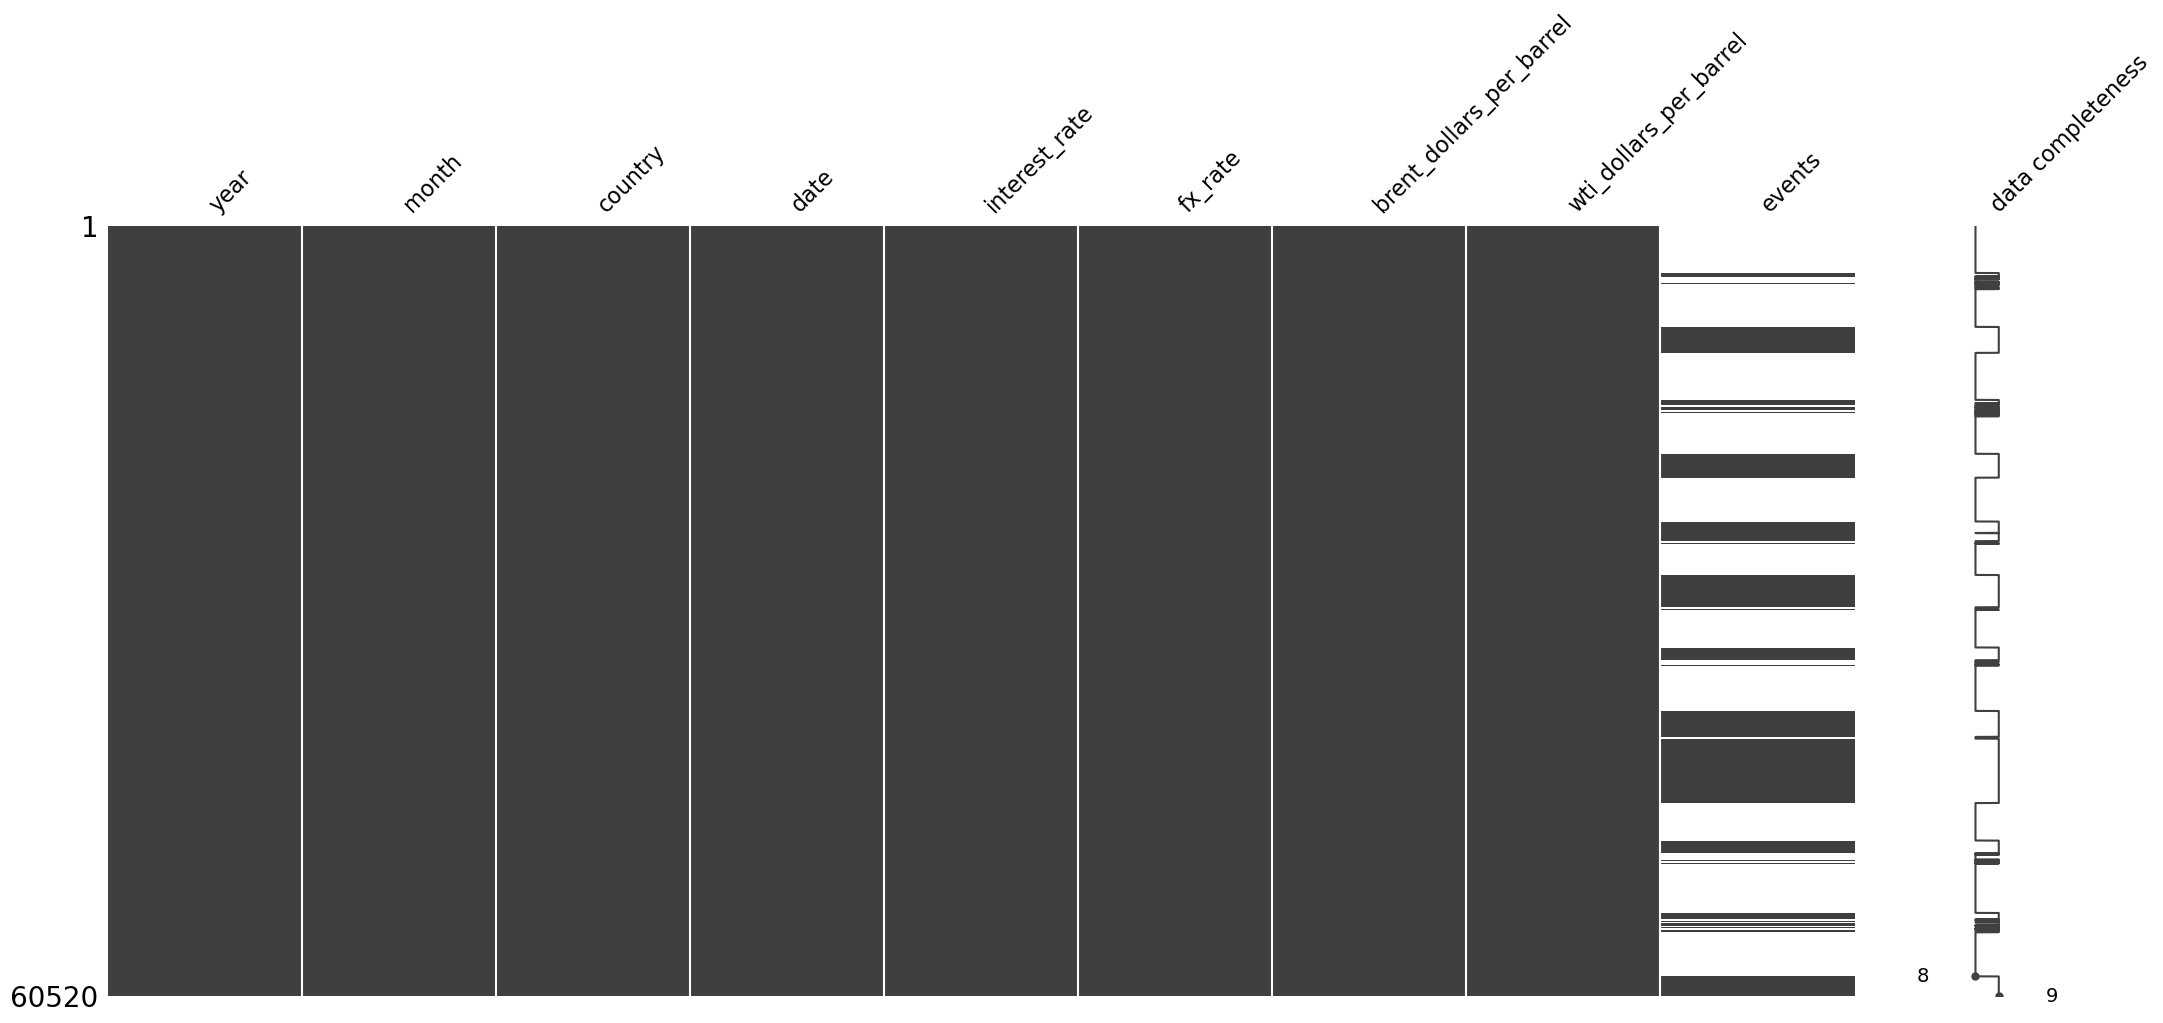

In [26]:
# Visualize missing data in the joined dataframe.
# Note: This will convert the Spark DataFrame to a Pandas DataFrame, which may not be efficient for large datasets.
msno.matrix(joined_df2.toPandas(), labels=True)
plt.show()


Missing Data from the `events` variable is expected. The missing variable is indicative that ACLED was not tracking or didn't need to record violent conflict data.
#### Missing Data treatment
- Missing data from the `events` variable will be assumed that `0` conflicts occured, all missing values will be filled in as 0.

In [28]:
# fill missing values in the events column with 0 (assuming missing means no events)
joined_df2 = joined_df2.withColumn('events', F.when(F.col('events').isNull(), 0).otherwise(F.col('events')))

## Check for missing values
missing_values = {col: joined_df2.filter(joined_df2[col].isNull()).count() for col in joined_df2.columns}
print("Missing values in joined_df2:\n--- --- --- --- --- --- --- --- ---")
for col, count in missing_values.items():
    print(f"{col}: {count}")


Missing values in joined_df2:
--- --- --- --- --- --- --- --- ---
year: 0
month: 0
country: 0
date: 0
interest_rate: 0
fx_rate: 0
brent_dollars_per_barrel: 0
wti_dollars_per_barrel: 0
events: 0


#### Outlier detection on `events` column

In [ ]:
# Outlier detection for the 'events' column in joined_df2